# Fase 1 — Recolección de datos y separación train/test

**TP1 — Aprendizaje Automático (72.75) — ITBA** · Consigna **2.1**

Cubrimos los pasos **2 (Recolección)** y **3 (Data Splitting)** del pipeline de la
Clase 3 (slide 16).

**Qué hacemos:** cargamos el dataset y lo separamos en train y test.

**Qué NO hacemos:** limpiar, imputar, escalar ni calcular ningún estadístico. Todo eso
va después y sólo con el train.

In [1]:
# ---------------------------------------------------------------------------
# Configuracion del entorno
# ---------------------------------------------------------------------------
# Agregamos la raiz del repo al path para poder importar el paquete src/.
# En VS Code esto ya lo resuelve .vscode/settings.json, pero lo dejamos explicito
# para que el notebook tambien funcione ejecutado desde la terminal.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():   # si estamos parados dentro de notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

# Constantes del proyecto: semilla, nombre del target y proporcion de test.
from src.config import RANDOM_SEED, TARGET, TEST_SIZE, FIGURES_DIR

# Funciones propias, documentadas en src/data.py
from src.data import (
    cargar_datos_crudos,   # lee el CSV y valida su estructura
    separar_train_test,    # parte el dataset en 80/20
    verificar_split,       # audita que la particion sea correcta
    guardar_splits,        # escribe train.csv y test.csv
    cargar_splits,         # vuelve a leerlos desde disco
)

pd.set_option("display.width", 110)
print(f"Semilla: {RANDOM_SEED} | Target: {TARGET} | Test: {TEST_SIZE:.0%}")

Semilla: 42 | Target: charges | Test: 20%


---

## 1. Carga de los datos

Leemos siempre desde `data/raw/insurance.csv`, nunca desde una API.

**Motivo:** `kagglehub` descarga la *última versión* publicada. Si esa versión cambiara,
los números de la presentación dejarían de reproducirse. El CSV está versionado en el
repositorio para congelar exactamente los datos que usamos.

In [2]:
# cargar_datos_crudos() lee el CSV y verifica que tenga las 7 columnas
# esperadas y 1338 filas. Si el archivo fuera otro, lanza un error explicito.
df = cargar_datos_crudos()

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1338 filas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.1 Verificación estructural

Controlamos que el archivo sea el esperado. **No modificamos ni descartamos nada**: el
diagnóstico de faltantes y outliers, con sus decisiones, va en la Fase 2 y sobre el train.

In [3]:
# Tipo de dato de cada columna.
print("--- Tipos de dato ---")
print(df.dtypes.to_string())

# Cantidad de valores nulos por columna.
print("\n--- Valores faltantes ---")
print(df.isna().sum().to_string())

# duplicated() marca filas repetidas; keep=False muestra todas las copias.
print(f"\n--- Filas exactamente duplicadas: {df.duplicated().sum()} ---")
display(df[df.duplicated(keep=False)])

--- Tipos de dato ---
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64

--- Valores faltantes ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

--- Filas exactamente duplicadas: 1 ---


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Encontramos:**

- **0 valores faltantes** en las 7 columnas.
- **Un par de filas idénticas** (índices 195 y 581). Lo anotamos porque el split podría
  mandar una copia a train y la otra a test. Lo auditamos más abajo.
- Tipos correctos. (En pandas 3.0 el texto tiene dtype `str`, no `object`.)

---

## 2. Separación train/test

### 2.1 Por qué separamos antes de limpiar

El enunciado numera "1. Limpieza" antes de "2.1 Separación", pero ese es el orden en que
se explican las consignas, no el orden en que se ejecutan. El pipeline de la Clase 3
pone **Data Splitting en el paso 3, antes de la limpieza (paso 4)**.

**El motivo es el data leakage.** Si imputáramos un valor usando la mediana del dataset
completo, esa mediana contendría información de las filas que van a ir al test. El modelo
entrenaría con un número que resume datos que se supone nunca vio, y el error de test
dejaría de ser una estimación honesta: saldría **demasiado optimista**.

Lo mismo vale para el IQR de los outliers, la media y el desvío del escalado, y el
encoding de las categóricas.

### 2.2 Método y proporción

| Decisión | Valor | Motivo |
|---|---|---|
| Método | Muestreo aleatorio simple | Clase 3, slide 30 |
| Proporción | 80% train / 20% test | Clase 3, slide 30 |
| Dev set fijo | No usamos | Validamos con k-fold sobre el train (Clase 2, slide 85) |
| Semilla | 42, en `src/config.py` | Sin ella cada ejecución daría otra partición y otro RMSE |

**Sobre la semilla:** la fijamos una sola vez y no la modificamos después. Probar varias
semillas y quedarse con la que da mejor resultado sería elegir la partición más
favorable en lugar del mejor modelo.

**Sobre el dev set:** la Clase 2 propone 60-20-20, con un dev fijo para elegir modelo.
Nosotros usamos 80-20 porque la validación la hace el k-fold dentro del train, que
aprovecha mejor los datos: cada fila se usa una vez para validar y el resto para entrenar.

In [4]:
# Comparamos cuantas filas quedarian de cada lado segun la proporcion elegida.
n = len(df)
opciones = [
    {"test_size": f"{t:.0%}", "n_train": n - round(n * t), "n_test": round(n * t)}
    for t in (0.15, 0.20, 0.25, 0.30)
]
pd.DataFrame(opciones)

,test_size,n_train,n_test
0,15%,1137,201
1,20%,1070,268
2,25%,1004,334
3,30%,937,401


**Elegimos 20%.** Con 15% el test queda en 201 filas, pocas para estimar el error de
forma estable. Con 30% le sacaríamos 133 filas al train sin ganar precisión relevante.
El 20% nos deja **1070 filas de train y 268 de test**.

### 2.3 Ejecución del split

In [5]:
# separar_train_test() usa train_test_split con shuffle y la semilla fija.
# Conserva el indice original del CSV para poder auditar cada fila.
train, test = separar_train_test(df)

print(f"Train: {train.shape[0]:5d} filas ({train.shape[0]/len(df):.1%})")
print(f"Test : {test.shape[0]:5d} filas ({test.shape[0]/len(df):.1%})")

Train:  1070 filas (80.0%)
Test :   268 filas (20.0%)


### 2.4 Auditoría del split

`verificar_split()` corre tres controles:

1. Que no se haya perdido ni duplicado ninguna fila.
2. Que ningún índice esté en los dos conjuntos.
3. Cuántas filas del test son **idénticas** a alguna del train.

In [6]:
# Devuelve un diccionario con el resultado de los tres controles.
chequeos = verificar_split(train, test)

for clave, valor in chequeos.items():
    print(f"{clave:32s}: {valor:,.4f}" if isinstance(valor, float) else f"{clave:32s}: {valor}")

n_train                         : 1070
n_test                          : 268
prop_test                       : 0.2003
solapamiento_indices            : 0
filas_identicas_compartidas     : 1
media_target_train              : 13,346.0897
media_target_test               : 12,968.3171


**Resultado:**

- `solapamiento_indices = 0` → la partición es correcta.
- `filas_identicas_compartidas = 1` → **el par de filas duplicadas quedó repartido**: la
  195 en train y la 581 en test. Hay una fila del test idéntica a una que el modelo verá
  al entrenar.

**Decidimos dejarla y documentarla**, por tres razones:

1. Los duplicados se tratan en el paso 4 del pipeline (Limpieza), que va **después** del
   split. Borrar filas antes sería adelantar una etapa.
2. Es **1 fila sobre 268: el 0.37%** del test.
3. Los modelos del TP son regresión lineal y polinómica, que ajustan coeficientes
   globales y **no memorizan observaciones individuales**. El efecto sobre el RMSE es
   inapreciable. (Sería grave en árboles o KNN, que sí memorizan.)

### 2.5 ¿El test representa la muestra?

La Clase 2 (slide 69) pide que el test *"represente los datos reales en los que el modelo
se usará"*. El sorteo aleatorio lo cumple en promedio; verificamos que en esta partición
concreta no haya quedado ningún desbalance.

In [7]:
# Comparamos media y desvio de cada variable numerica entre train y test.
num_cols = ["age", "bmi", "children", TARGET]

comparacion = pd.DataFrame({
    "train_media": train[num_cols].mean(),
    "test_media": test[num_cols].mean(),
    "train_desvio": train[num_cols].std(),
    "test_desvio": test[num_cols].std(),
})
# Diferencia porcentual entre las medias, para leerla de un vistazo.
comparacion["dif_medias_%"] = (
    100 * (comparacion["test_media"] - comparacion["train_media"]) / comparacion["train_media"]
)
comparacion.round(2)

,train_media,test_media,train_desvio,test_desvio,dif_medias_%
age,39.36,38.61,14.07,13.96,-1.90
bmi,30.56,31.07,6.04,6.31,1.68
children,1.11,1.04,1.22,1.16,-5.66
charges,13346.09,12968.32,12019.51,12483.20,-2.83


In [8]:
# Para las categoricas comparamos la proporcion de cada nivel (en %).
for col in ["sex", "smoker", "region"]:
    prop = pd.DataFrame({
        "train_%": 100 * train[col].value_counts(normalize=True),
        "test_%": 100 * test[col].value_counts(normalize=True),
    })
    prop["dif_pp"] = prop["test_%"] - prop["train_%"]   # diferencia en puntos porcentuales
    print(f"--- {col} ---")
    print(prop.round(2).to_string())
    print()

--- sex ---
        train_%  test_%  dif_pp
sex                            
female    48.79   52.24    3.45
male      51.21   47.76   -3.45

--- smoker ---
        train_%  test_%  dif_pp
smoker                         
no        79.44   79.85    0.41
yes       20.56   20.15   -0.41

--- region ---
           train_%  test_%  dif_pp
region                            
northeast    24.95   21.27   -3.68
northwest    23.93   25.75    1.82
southeast    26.45   30.22    3.78
southwest    24.67   22.76   -1.91



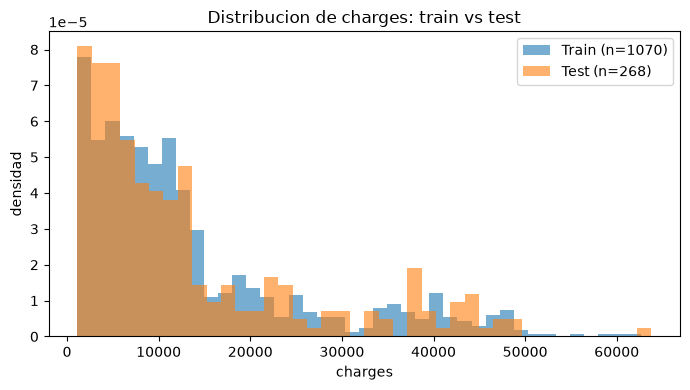

In [9]:
# Superponemos las distribuciones del target. density=True normaliza las areas,
# para que los conjuntos sean comparables pese a tener distinto tamano.
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(train[TARGET], bins=40, density=True, alpha=0.6, label=f"Train (n={len(train)})")
ax.hist(test[TARGET], bins=40, density=True, alpha=0.6, label=f"Test (n={len(test)})")
ax.set_title("Distribucion de charges: train vs test")
ax.set_xlabel("charges")
ax.set_ylabel("densidad")
ax.legend()

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "01_distribucion_charges_train_test.png", dpi=150, bbox_inches="tight")
plt.show()

Las medias difieren en pocos puntos porcentuales, las proporciones de las categóricas
son similares y las distribuciones se superponen. **El test es representativo.**

El histograma muestra además que `charges` es muy asimétrica, con una cola larga a la
derecha. Lo analizamos en la Fase 2.

---

## 3. Guardado de los splits

Los guardamos en `data/processed/` conservando el índice original.

Desde la Fase 2 en adelante, **ningún notebook vuelve a abrir el CSV crudo**: todos
entran por `cargar_splits()`. Así es imposible calcular por error un estadístico sobre el
dataset completo.

In [10]:
# Escribimos los CSV y los volvemos a leer para confirmar que se guardaron bien.
guardar_splits(train, test)

train_recargado, test_recargado = cargar_splits()
print(f"train.csv -> {train_recargado.shape}")
print(f"test.csv  -> {test_recargado.shape}")
print(f"Indices preservados: {(train_recargado.index == train.index).all()}")

train.csv -> (1070, 7)
test.csv  -> (268, 7)
Indices preservados: True


> `data/processed/` está en el `.gitignore`: no lo versionamos porque se regenera con
> `python -m src.data`. Lo que garantiza la reproducibilidad es la semilla fija más el CSV
> crudo versionado, no los archivos derivados.

---

## Conclusiones de la Fase 1

| Decisión | Valor | Motivo |
|---|---|---|
| Momento del split | Antes de limpiar | Paso 3 del pipeline; evitar data leakage |
| Método | Muestreo aleatorio simple | Clase 3, slide 30 |
| Proporción | 80/20 → 1070 / 268 filas | Clase 3, slide 30 |
| Semilla | 42 | Reproducibilidad |
| Fila duplicada repartida | Se mantiene, documentada | Corresponde al paso 4; es el 0.37% del test |

**El test queda separado y cerrado. No lo volvemos a mirar hasta la Fase 6.**

**Siguiente:** Fase 2 — Limpieza de datos y EDA sobre el train.